# Multimodal House Price — Simplified Fusion Notebook

Combines:
- **Tabular model**: sklearn ensemble (RF + ExtraTrees)
- **Image model**: CLIP ViT-B/32 → MLP

Two fusion approaches:
1. **Stage 1** — Prediction blending (simple baseline)
2. **Stage 2** — Feature-level fusion MLP (recommended)

## 0. Setup

In [118]:
import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import clip

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
RANDOM_STATE = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 1. Load & Align Both Datasets

`house_id` is the key that links tabular data to images.

This house notebook uses strict linked inputs produced by `scripts/build_house_multimodal_inputs.py`:
- `data/house/satilir_properties_house_feature_engineered_with_house_id.csv`
- `data/house/satilir_house_id_price_folder.csv`

These files contain only high-confidence matches between house tabular rows and photo folders.

In [119]:
# -- Paths ---------------------------------------------------------------------
TABULAR_CSV = Path('../../data/house/satilir_properties_house_feature_engineered_with_house_id.csv')
IMAGE_CSV = Path('../../data/house/satilir_house_id_price_folder.csv')

PHOTO_ROOT_CANDIDATES = [
    Path('../../satilir_photos/satilir_photos'),
    Path('../../satilir_photos'),
]
PHOTOS_DIR = next((p for p in PHOTO_ROOT_CANDIDATES if p.exists()), PHOTO_ROOT_CANDIDATES[0])

OUTPUT_DIR = Path('../../models/multimodal/house')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
MAX_IMAGES = 20
IMG_SIZE = 224

if not TABULAR_CSV.exists():
    raise FileNotFoundError(f'Missing tabular multimodal file: {TABULAR_CSV}')
if not IMAGE_CSV.exists():
    raise FileNotFoundError(f'Missing image mapping file: {IMAGE_CSV}')

print('Tabular CSV:', TABULAR_CSV)
print('Image CSV  :', IMAGE_CSV)
print('Photos dir :', PHOTOS_DIR.resolve())

Tabular CSV: ..\..\data\house\satilir_properties_house_feature_engineered_with_house_id.csv
Image CSV  : ..\..\data\house\satilir_house_id_price_folder.csv
Photos dir : E:\Coding\ai_project\satilir_photos\satilir_photos


In [120]:
df_tab = pd.read_csv(TABULAR_CSV)
df_tab['house_id'] = pd.to_numeric(df_tab['house_id'], errors='coerce').astype('Int64')
df_tab = df_tab.dropna(subset=['house_id']).reset_index(drop=True)
print('Tabular shape:', df_tab.shape)

Tabular shape: (1173, 42)


In [121]:
# ── Load image CSV & get image paths ─────────────────────────────────────────
df_img = pd.read_csv(IMAGE_CSV)
df_img['house_id'] = pd.to_numeric(df_img['house_id'], errors='coerce').astype('Int64')
df_img['price']    = pd.to_numeric(df_img['price'], errors='coerce')
df_img = df_img.dropna(subset=['house_id', 'price', 'image_folder_name']).reset_index(drop=True)

def get_image_paths(folder_name):
    folder = PHOTOS_DIR / str(folder_name)
    if not folder.exists():
        return []
    return [f for f in sorted(folder.iterdir()) if f.suffix.lower() in VALID_EXT]

df_img['img_paths'] = df_img['image_folder_name'].apply(get_image_paths)
df_img['n_images']  = df_img['img_paths'].apply(len)
df_img = df_img[df_img['n_images'] >= 1].reset_index(drop=True)
print('Image CSV shape after filtering:', df_img.shape)

Image CSV shape after filtering: (1173, 10)


In [122]:
# ── Merge on house_id (inner join) ───────────────────────────────────────────
img_cols = ['house_id', 'image_folder_name', 'img_paths', 'n_images']
if 'price' not in df_tab.columns:
    img_cols.append('price')

df = df_tab.merge(df_img[img_cols], on='house_id', how='inner').reset_index(drop=True)
print(f'Merged rows: {len(df):,}  (tabular: {len(df_tab):,}, image: {len(df_img):,})')

Merged rows: 1,173  (tabular: 1,173, image: 1,173)


## 2. Split the Data

Split once by `house_id`. Everything — tabular and image — uses this same split.

In [123]:
PRICE_COL = 'num__price' if 'num__price' in df.columns else 'price'

# Remove extreme prices
df = df[df[PRICE_COL] < 10_000_000].reset_index(drop=True)

# Stratified split on price bins
df['price_bin'] = pd.qcut(df[PRICE_COL], q=5, labels=False, duplicates='drop')
all_ids = df['house_id'].unique()
id_to_bin = df.drop_duplicates('house_id').set_index('house_id')['price_bin']

train_ids, temp_ids = train_test_split(
    all_ids, test_size=0.28, random_state=RANDOM_STATE,
    stratify=id_to_bin.loc[all_ids]
)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=RANDOM_STATE)

train_df = df[df['house_id'].isin(train_ids)].copy().reset_index(drop=True)
val_df   = df[df['house_id'].isin(val_ids)].copy().reset_index(drop=True)
test_df  = df[df['house_id'].isin(test_ids)].copy().reset_index(drop=True)

# Cap outlier prices on train only
price_cap = float(train_df[PRICE_COL].quantile(0.98))
train_df = train_df[train_df[PRICE_COL] <= price_cap].reset_index(drop=True)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

Train: 829  Val: 164  Test: 165


## 3. Tabular Model

In [124]:
# ── Define features ──────────────────────────────────────────────────────────
EXCLUDE_COLS = {'house_id', PRICE_COL, 'price_bin', 'image_folder_name',
                'img_paths', 'n_images', 'price'}

TAB_FEATURES = [c for c in train_df.columns if c not in EXCLUDE_COLS
                and train_df[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]]

print(f'Tabular feature count: {len(TAB_FEATURES)}')

X_train_tab = train_df[TAB_FEATURES].values
X_val_tab   = val_df[TAB_FEATURES].values
X_test_tab  = test_df[TAB_FEATURES].values

y_train = train_df[PRICE_COL].values.astype(float)
y_val   = val_df[PRICE_COL].values.astype(float)
y_test  = test_df[PRICE_COL].values.astype(float)

Tabular feature count: 40


In [125]:
# ── Train RF + ExtraTrees ensemble (MAE-focused search) ──────────────────────
from sklearn.ensemble import ExtraTreesRegressor

rf = RandomForestRegressor(
    n_estimators=2200,
    max_depth=None,
    max_features=0.85,
    min_samples_split=3,
    min_samples_leaf=1,
    bootstrap=True,
    criterion='absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
 )

print('Fitting RF...')
rf.fit(X_train_tab, y_train)
rf_pred_train = np.clip(rf.predict(X_train_tab), 0, None)
rf_pred_val   = np.clip(rf.predict(X_val_tab), 0, None)
rf_pred_test  = np.clip(rf.predict(X_test_tab), 0, None)

et_candidates = [
    {'n_estimators': 1800, 'max_depth': 20,   'max_features': 0.82, 'min_samples_split': 3},
    {'n_estimators': 2200, 'max_depth': 20,   'max_features': 0.88, 'min_samples_split': 4},
    {'n_estimators': 2000, 'max_depth': None, 'max_features': 0.80, 'min_samples_split': 2},
    {'n_estimators': 2400, 'max_depth': 24,   'max_features': 0.90, 'min_samples_split': 3},
]

best_et_model = None
best_et_params = None
best_et_val_mae = float('inf')
best_et_pred_train = None
best_et_pred_val = None
best_et_pred_test = None

for i, params in enumerate(et_candidates, start=1):
    et_try = ExtraTreesRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        max_features=params['max_features'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=1,
        bootstrap=False,
        criterion='absolute_error',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    print(f"Fitting ExtraTrees candidate {i}/{len(et_candidates)}...")
    et_try.fit(X_train_tab, y_train)

    et_val = np.clip(et_try.predict(X_val_tab), 0, None)
    et_val_mae = mean_absolute_error(y_val, et_val)
    print(f"  candidate {i} val MAE: {et_val_mae:,.0f}")

    if et_val_mae < best_et_val_mae:
        best_et_val_mae = et_val_mae
        best_et_model = et_try
        best_et_params = params
        best_et_pred_train = np.clip(et_try.predict(X_train_tab), 0, None)
        best_et_pred_val = et_val
        best_et_pred_test = np.clip(et_try.predict(X_test_tab), 0, None)

# Optional variance reduction: 2-seed ET average if it improves val MAE.
et_second = ExtraTreesRegressor(
    n_estimators=best_et_params['n_estimators'],
    max_depth=best_et_params['max_depth'],
    max_features=best_et_params['max_features'],
    min_samples_split=best_et_params['min_samples_split'],
    min_samples_leaf=1,
    bootstrap=False,
    criterion='absolute_error',
    random_state=RANDOM_STATE + 17,
    n_jobs=-1,
 )
print('Fitting ExtraTrees second seed...')
et_second.fit(X_train_tab, y_train)

et2_pred_train = np.clip(et_second.predict(X_train_tab), 0, None)
et2_pred_val   = np.clip(et_second.predict(X_val_tab), 0, None)
et2_pred_test  = np.clip(et_second.predict(X_test_tab), 0, None)

et_avg_train = np.clip(0.5 * best_et_pred_train + 0.5 * et2_pred_train, 0, None)
et_avg_val   = np.clip(0.5 * best_et_pred_val + 0.5 * et2_pred_val, 0, None)
et_avg_test  = np.clip(0.5 * best_et_pred_test + 0.5 * et2_pred_test, 0, None)

if mean_absolute_error(y_val, et_avg_val) <= mean_absolute_error(y_val, best_et_pred_val):
    et_models = [best_et_model, et_second]
    et_pred_train, et_pred_val, et_pred_test = et_avg_train, et_avg_val, et_avg_test
    print('Using 2-seed ExtraTrees average (better val MAE).')
else:
    et_models = [best_et_model]
    et_pred_train, et_pred_val, et_pred_test = best_et_pred_train, best_et_pred_val, best_et_pred_test
    print('Using single best ExtraTrees model.')

def _et_predict(X):
    if len(et_models) == 1:
        return np.clip(et_models[0].predict(X), 0, None)
    pred = np.zeros(X.shape[0], dtype=float)
    for model in et_models:
        pred += model.predict(X)
    return np.clip(pred / len(et_models), 0, None)

# Fine RF weight search by validation MAE.
best_tab_alpha, best_tab_val_mae = 0.5, float('inf')
for a in np.linspace(0, 1, 1001):
    pred_val = np.clip(a * rf_pred_val + (1 - a) * et_pred_val, 0, None)
    mae = mean_absolute_error(y_val, pred_val)
    if mae < best_tab_val_mae:
        best_tab_val_mae = mae
        best_tab_alpha = a

def tab_predict(X):
    return np.clip(best_tab_alpha * rf.predict(X) + (1 - best_tab_alpha) * _et_predict(X), 0, None)

tab_pred_train = np.clip(best_tab_alpha * rf_pred_train + (1 - best_tab_alpha) * et_pred_train, 0, None)
tab_pred_val   = np.clip(best_tab_alpha * rf_pred_val + (1 - best_tab_alpha) * et_pred_val, 0, None)
tab_pred_test  = np.clip(best_tab_alpha * rf_pred_test + (1 - best_tab_alpha) * et_pred_test, 0, None)

print('Best ET params:', best_et_params)
print(f'Best tabular RF weight (val MAE): {best_tab_alpha:.3f}')
print(f'Tabular val MAE               : {mean_absolute_error(y_val, tab_pred_val):,.0f}')
print(f'Tabular val R2                : {r2_score(y_val, tab_pred_val):.4f}')

Fitting RF...
Fitting ExtraTrees candidate 1/4...
  candidate 1 val MAE: 76,291
Fitting ExtraTrees candidate 2/4...
  candidate 2 val MAE: 76,278
Fitting ExtraTrees candidate 3/4...
  candidate 3 val MAE: 76,525
Fitting ExtraTrees candidate 4/4...
  candidate 4 val MAE: 76,096
Fitting ExtraTrees second seed...
Using single best ExtraTrees model.
Best ET params: {'n_estimators': 2400, 'max_depth': 24, 'max_features': 0.9, 'min_samples_split': 3}
Best tabular RF weight (val MAE): 0.000
Tabular val MAE               : 76,096
Tabular val R2                : 0.5316


## 4. Image Model — Extract CLIP Embeddings

Extract once, save to disk. Reused in both Stage 1 and Stage 2.

In [126]:
# ── Load CLIP ────────────────────────────────────────────────────────────────
clip_model, _ = clip.load('ViT-B/32', device=device)
clip_model     = clip_model.float().eval()
CLIP_DIM       = clip_model.visual.output_dim  # 512

for param in clip_model.parameters():
    param.requires_grad = False

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std =(0.26862954, 0.26130258, 0.27577711),
    ),
])
print(f'CLIP loaded. Each house → {CLIP_DIM}-d embedding.')

CLIP loaded. Each house → 512-d embedding.


In [127]:
# ── Extract & cache embeddings ───────────────────────────────────────────────
EMBED_CACHE = OUTPUT_DIR / 'multimodal_embeddings.pt'

@torch.no_grad()
def embed_house(img_paths):
    tensors = []
    for path in img_paths[:MAX_IMAGES]:
        try:
            tensors.append(tfm(Image.open(path).convert('RGB')))
        except Exception:
            continue
    if not tensors:
        return torch.zeros(CLIP_DIM)
    batch = torch.stack(tensors).to(device)
    embs  = clip_model.encode_image(batch)
    embs  = F.normalize(embs.float(), dim=-1)
    return embs.mean(dim=0).cpu()

if EMBED_CACHE.exists():
    embeddings = torch.load(EMBED_CACHE)
    print(f'Loaded {len(embeddings):,} cached embeddings.')
else:
    print('Extracting embeddings (runs once)...')
    embeddings = {}
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Embedding'):
        hid = int(row['house_id'])
        if hid not in embeddings:
            embeddings[hid] = embed_house(row['img_paths'])
    torch.save(embeddings, EMBED_CACHE)
    print(f'Done. {len(embeddings):,} embeddings saved.')

Loaded 1,173 cached embeddings.


## 5. Shared helpers (log-price normalisation & MdAPE)

In [128]:
# Log-normalise target based on train distribution only
log_prices = np.log1p(y_train)
Y_MEAN = float(log_prices.mean())
Y_STD  = float(log_prices.std()) + 1e-8

def to_price(x_norm):
    return np.expm1(np.clip(x_norm * Y_STD + Y_MEAN, 6.0, 16.5))

def norm_price(price):
    return (np.log1p(price) - Y_MEAN) / Y_STD

def mdape(true, pred):
    return float(np.median(np.abs(true - pred) / (true + 1e-8)) * 100)

## Stage 1 — Prediction Blending

```
Tabular ensemble → pred_tab  ─┐
                               ├→ α·pred_tab + (1-α)·pred_img → final price
CLIP → MLP       → pred_img  ─┘
```

In [129]:
# ── Image-only dataset & loaders ─────────────────────────────────────────────
class ImageDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        emb    = embeddings[int(row['house_id'])]
        target = torch.tensor(norm_price(float(row[PRICE_COL])), dtype=torch.float32)
        return emb, target

BATCH_SIZE = 64
img_train_loader = DataLoader(ImageDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
img_val_loader   = DataLoader(ImageDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
img_test_loader  = DataLoader(ImageDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

In [130]:
# ── Train image-only MLP ─────────────────────────────────────────────────────
EPOCHS   = 100
LR       = 3e-4
PATIENCE = 10

img_model = nn.Sequential(
    nn.LayerNorm(CLIP_DIM),
    nn.Linear(CLIP_DIM, 512), nn.GELU(), nn.Dropout(0.3),
    nn.Linear(512, 128),      nn.GELU(), nn.Dropout(0.15),
    nn.Linear(128, 1),
).to(device)

criterion = nn.HuberLoss(delta=0.5)
optimizer = torch.optim.AdamW(img_model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(img_train_loader), epochs=EPOCHS
)

@torch.no_grad()
def eval_img_model(model, loader):
    model.eval()
    preds, targets = [], []
    for emb, target in loader:
        p = model(emb.to(device)).squeeze(1)
        preds.append(p.cpu().numpy())
        targets.append(target.numpy())
    return to_price(np.concatenate(preds)), to_price(np.concatenate(targets))

best_mdape, best_weights, no_improve = float('inf'), None, 0
print(f'{"Ep":>4} | {"Loss":>7} | {"Val MAE":>11} | {"MdAPE":>7}')
print('-' * 38)

for epoch in range(1, EPOCHS + 1):
    img_model.train()
    total_loss = 0.0
    for emb, target in img_train_loader:
        emb, target = emb.to(device), target.to(device)
        pred = img_model(emb).squeeze(1)
        loss = criterion(pred, target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    preds_azn, targets_azn = eval_img_model(img_model, img_val_loader)
    val_mae   = mean_absolute_error(targets_azn, preds_azn)
    val_mdape = mdape(targets_azn, preds_azn)
    marker = '*' if val_mdape < best_mdape else ' '
    if val_mdape < best_mdape:
        best_mdape   = val_mdape
        best_weights = {k: v.clone() for k, v in img_model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
    print(f'{marker}{epoch:3d}/{EPOCHS} | {total_loss/len(img_train_loader):.4f} | {val_mae:>11,.0f} | {val_mdape:>6.2f}%')
    if no_improve >= PATIENCE:
        print('Early stop'); break

img_model.load_state_dict(best_weights)
print(f'\nBest val MdAPE (image-only): {best_mdape:.2f}%')

  Ep |    Loss |     Val MAE |   MdAPE
--------------------------------------
*  1/100 | 0.2911 |     190,632 |  63.13%
*  2/100 | 0.2863 |     189,496 |  61.18%
*  3/100 | 0.2827 |     188,368 |  58.35%
*  4/100 | 0.2785 |     187,215 |  56.48%
*  5/100 | 0.2727 |     186,016 |  56.16%
*  6/100 | 0.2686 |     184,703 |  56.00%
*  7/100 | 0.2642 |     183,225 |  55.09%
*  8/100 | 0.2596 |     181,646 |  54.25%
*  9/100 | 0.2527 |     179,860 |  53.46%
* 10/100 | 0.2493 |     177,855 |  53.45%
* 11/100 | 0.2412 |     175,679 |  52.88%
  12/100 | 0.2358 |     173,260 |  52.93%
* 13/100 | 0.2297 |     170,649 |  50.55%
* 14/100 | 0.2217 |     167,666 |  49.85%
* 15/100 | 0.2124 |     164,279 |  48.91%
* 16/100 | 0.2048 |     160,776 |  45.62%
* 17/100 | 0.1941 |     156,851 |  45.33%
* 18/100 | 0.1891 |     153,494 |  45.05%
  19/100 | 0.1800 |     150,545 |  46.02%
* 20/100 | 0.1756 |     147,887 |  42.79%
* 21/100 | 0.1664 |     145,548 |  40.52%
* 22/100 | 0.1635 |     143,625 |  39.09

In [131]:
# -- Stage 1 blend search: global alpha vs price-bin alpha ---------------------
img_pred_train, _ = eval_img_model(img_model, img_train_loader)
img_pred_val,   _ = eval_img_model(img_model, img_val_loader)
img_pred_test,  _ = eval_img_model(img_model, img_test_loader)

alpha_grid = np.linspace(0, 1, 1001)

# 1) Global alpha by validation MAE
global_alpha, global_val_mae = 0.5, float('inf')
for alpha in alpha_grid:
    pred_val = np.clip(alpha * tab_pred_val + (1 - alpha) * img_pred_val, 0, None)
    mae = mean_absolute_error(y_val, pred_val)
    if mae < global_val_mae:
        global_val_mae = mae
        global_alpha = alpha

global_blended_val = np.clip(global_alpha * tab_pred_val + (1 - global_alpha) * img_pred_val, 0, None)
global_blended_test = np.clip(global_alpha * tab_pred_test + (1 - global_alpha) * img_pred_test, 0, None)

# 2) Price-bin alphas by validation MAE
n_bins = 5
bin_edges = np.quantile(y_train, np.linspace(0, 1, n_bins + 1))
bin_edges[0] = bin_edges[0] - 1e-6
bin_edges[-1] = bin_edges[-1] + 1e-6

val_bin_ids = np.digitize(y_val, bin_edges[1:-1], right=False)
test_bin_ids = np.digitize(y_test, bin_edges[1:-1], right=False)

bin_alphas = {}
for b in range(n_bins):
    mask = val_bin_ids == b
    if mask.sum() < 10:
        bin_alphas[b] = float(global_alpha)
        continue

    best_a, best_mae_b = float(global_alpha), float('inf')
    for a in alpha_grid:
        pred_b = np.clip(a * tab_pred_val[mask] + (1 - a) * img_pred_val[mask], 0, None)
        mae_b = mean_absolute_error(y_val[mask], pred_b)
        if mae_b < best_mae_b:
            best_mae_b = mae_b
            best_a = float(a)
    bin_alphas[b] = best_a

def blend_by_bin(tab_pred, img_pred, bin_ids, alphas, default_alpha):
    out = np.empty_like(tab_pred, dtype=float)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.any():
            a = alphas.get(b, default_alpha)
            out[mask] = a * tab_pred[mask] + (1 - a) * img_pred[mask]
    return np.clip(out, 0, None)

bin_blended_val = blend_by_bin(tab_pred_val, img_pred_val, val_bin_ids, bin_alphas, float(global_alpha))
bin_blended_test = blend_by_bin(tab_pred_test, img_pred_test, test_bin_ids, bin_alphas, float(global_alpha))
bin_val_mae = mean_absolute_error(y_val, bin_blended_val)

# Select by validation MAE. Keep best_alpha scalar for downstream save cell.
if bin_val_mae <= global_val_mae:
    blend_mode = 'bin-wise'
    blended_val = bin_blended_val
    blended_test = bin_blended_test
    best_alpha = float(global_alpha)
    best_alpha_by_bin = {int(k): float(v) for k, v in bin_alphas.items()}
else:
    blend_mode = 'global'
    blended_val = global_blended_val
    blended_test = global_blended_test
    best_alpha = float(global_alpha)
    best_alpha_by_bin = None

print(f'Blend mode selected          : {blend_mode}')
print(f'Global alpha (tabular weight): {global_alpha:.3f}')
print(f'Global val MAE               : {global_val_mae:,.0f}')
print(f'Bin-wise val MAE             : {bin_val_mae:,.0f}')
if best_alpha_by_bin is not None:
    print('Bin alphas (tabular weight):', {k: round(v, 3) for k, v in best_alpha_by_bin.items()})
print()
print('Stage 1 TEST RESULTS')
print(f'  R2    : {r2_score(y_test, blended_test):.4f}')
print(f'  MAE   : {mean_absolute_error(y_test, blended_test):,.0f} AZN')
print(f'  MdAPE : {mdape(y_test, blended_test):.2f}%')
print()
print(f'  (tabular-only R2) : {r2_score(y_test, tab_pred_test):.4f}')
print(f'  (image-only  R2)  : {r2_score(y_test, img_pred_test):.4f}')

Blend mode selected          : bin-wise
Global alpha (tabular weight): 1.000
Global val MAE               : 76,096
Bin-wise val MAE             : 74,566
Bin alphas (tabular weight): {0: 0.941, 1: 1.0, 2: 0.515, 3: 0.798, 4: 1.0}

Stage 1 TEST RESULTS
  R2    : 0.6991
  MAE   : 49,649 AZN
  MdAPE : 14.64%

  (tabular-only R2) : 0.6919
  (image-only  R2)  : 0.4225


## Stage 2 — Feature-Level Fusion MLP

```
CLIP embedding [512]      ─────────────────────┐
                                                ├→ Concat → MLP → price
Tabular features [N_tab] → Encoder → Norm  ───┘
```

In [132]:
# ── Normalise tabular features for the neural net ─────────────────────────────
scaler = StandardScaler()
X_train_tab_norm = scaler.fit_transform(X_train_tab).astype(np.float32)
X_val_tab_norm   = scaler.transform(X_val_tab).astype(np.float32)
X_test_tab_norm  = scaler.transform(X_test_tab).astype(np.float32)

N_TAB = X_train_tab_norm.shape[1]
print(f'Tabular feature dim : {N_TAB}')
print(f'CLIP embedding dim  : {CLIP_DIM}')

Tabular feature dim : 40
CLIP embedding dim  : 512


In [133]:
# ── Multimodal dataset & loaders ─────────────────────────────────────────────
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tab_features_norm):
        self.df  = dataframe.reset_index(drop=True)
        self.tab = torch.tensor(tab_features_norm, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        emb    = embeddings[int(row['house_id'])]
        tab    = self.tab[idx]
        target = torch.tensor(norm_price(float(row[PRICE_COL])), dtype=torch.float32)
        return emb, tab, target

mm_train_loader = DataLoader(MultimodalDataset(train_df, X_train_tab_norm), batch_size=BATCH_SIZE, shuffle=True)
mm_val_loader   = DataLoader(MultimodalDataset(val_df,   X_val_tab_norm),   batch_size=BATCH_SIZE, shuffle=False)
mm_test_loader  = DataLoader(MultimodalDataset(test_df,  X_test_tab_norm),  batch_size=BATCH_SIZE, shuffle=False)
print('Multimodal DataLoaders ready.')

Multimodal DataLoaders ready.


In [134]:
# ── Fusion model definition ───────────────────────────────────────────────────
class FusionModel(nn.Module):
    def __init__(self, clip_dim, tab_dim, img_hidden=256, tab_hidden=128, dropout=0.3):
        super().__init__()

        self.img_branch = nn.Sequential(
            nn.LayerNorm(clip_dim),
            nn.Linear(clip_dim, img_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.tab_branch = nn.Sequential(
            nn.BatchNorm1d(tab_dim),
            nn.Linear(tab_dim, tab_hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(tab_hidden * 2, tab_hidden),
            nn.GELU(),
        )
        fused_dim = img_hidden + tab_hidden
        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 64),        nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, img_emb, tab_feat):
        return self.head(torch.cat([self.img_branch(img_emb),
                                    self.tab_branch(tab_feat)], dim=1)).squeeze(1)

mm_model = FusionModel(CLIP_DIM, N_TAB).to(device)
print(f'Fusion model params: {sum(p.numel() for p in mm_model.parameters()):,}')

Fusion model params: 291,665


In [135]:
# ── Train fusion model ───────────────────────────────────────────────────────
MM_EPOCHS   = 150
MM_LR       = 3e-4
MM_PATIENCE = 15

mm_criterion = nn.HuberLoss(delta=0.5)
mm_optimizer = torch.optim.AdamW(mm_model.parameters(), lr=MM_LR, weight_decay=1e-2)
mm_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    mm_optimizer, max_lr=MM_LR,
    steps_per_epoch=len(mm_train_loader), epochs=MM_EPOCHS
)

@torch.no_grad()
def eval_mm_model(model, loader):
    model.eval()
    preds, targets = [], []
    for emb, tab, target in loader:
        p = model(emb.to(device), tab.to(device))
        preds.append(p.cpu().numpy())
        targets.append(target.numpy())
    return to_price(np.concatenate(preds)), to_price(np.concatenate(targets))

mm_best_mdape, mm_best_weights, mm_no_improve = float('inf'), None, 0
history = {'loss': [], 'val_mdape': [], 'val_mae': []}

print(f'{"Ep":>4} | {"Loss":>7} | {"Val MAE":>11} | {"MdAPE":>7}')
print('-' * 38)

for epoch in range(1, MM_EPOCHS + 1):
    mm_model.train()
    total_loss = 0.0
    for emb, tab, target in mm_train_loader:
        emb, tab, target = emb.to(device), tab.to(device), target.to(device)
        pred = mm_model(emb, tab)
        loss = mm_criterion(pred, target)
        mm_optimizer.zero_grad(); loss.backward(); mm_optimizer.step()
        total_loss += loss.item()
    mm_scheduler.step()

    preds_azn, targets_azn = eval_mm_model(mm_model, mm_val_loader)
    val_mae   = mean_absolute_error(targets_azn, preds_azn)
    val_mdape = mdape(targets_azn, preds_azn)

    history['loss'].append(total_loss / len(mm_train_loader))
    history['val_mae'].append(val_mae)
    history['val_mdape'].append(val_mdape)

    marker = '*' if val_mdape < mm_best_mdape else ' '
    if val_mdape < mm_best_mdape:
        mm_best_mdape   = val_mdape
        mm_best_weights = {k: v.clone() for k, v in mm_model.state_dict().items()}
        mm_no_improve   = 0
    else:
        mm_no_improve += 1
    print(f'{marker}{epoch:3d}/{MM_EPOCHS} | {total_loss/len(mm_train_loader):.4f} | {val_mae:>11,.0f} | {val_mdape:>6.2f}%')
    if mm_no_improve >= MM_PATIENCE:
        print('Early stop'); break

mm_model.load_state_dict(mm_best_weights)
print(f'\nBest val MdAPE (fusion): {mm_best_mdape:.2f}%')

  Ep |    Loss |     Val MAE |   MdAPE
--------------------------------------
*  1/150 | 0.2970 |     190,439 |  67.41%
*  2/150 | 0.2895 |     188,392 |  64.38%
*  3/150 | 0.2809 |     186,628 |  58.93%
*  4/150 | 0.2759 |     184,827 |  54.55%
*  5/150 | 0.2691 |     182,874 |  53.47%
*  6/150 | 0.2645 |     180,506 |  51.66%
*  7/150 | 0.2573 |     177,392 |  50.53%
*  8/150 | 0.2470 |     173,575 |  46.06%
*  9/150 | 0.2373 |     168,485 |  43.54%
* 10/150 | 0.2265 |     162,625 |  42.78%
* 11/150 | 0.2113 |     155,585 |  40.04%
  12/150 | 0.1951 |     147,064 |  40.37%
* 13/150 | 0.1756 |     138,875 |  33.06%
* 14/150 | 0.1631 |     132,769 |  30.64%
  15/150 | 0.1482 |     128,786 |  32.60%
  16/150 | 0.1410 |     126,559 |  31.75%
  17/150 | 0.1249 |     126,997 |  31.29%
  18/150 | 0.1211 |     125,975 |  31.75%
  19/150 | 0.1158 |     124,273 |  31.96%
  20/150 | 0.1110 |     121,664 |  32.29%
  21/150 | 0.1067 |     118,692 |  32.17%
  22/150 | 0.1004 |     116,306 |  31.58

## 6. Final Results

In [136]:
mm_preds_test, mm_targets_test = eval_mm_model(mm_model, mm_test_loader)

results = {
    'Tabular only (RF+ExtraTrees)' : (r2_score(y_test, tab_pred_test),
                                       mean_absolute_error(y_test, tab_pred_test),
                                       mdape(y_test, tab_pred_test)),
    'Image only (CLIP+MLP)'        : (r2_score(y_test, img_pred_test),
                                      mean_absolute_error(y_test, img_pred_test),
                                      mdape(y_test, img_pred_test)),
    'Stage 1: Blend'               : (r2_score(y_test, blended_test),
                                      mean_absolute_error(y_test, blended_test),
                                      mdape(y_test, blended_test)),
    'Stage 2: Fusion MLP'          : (r2_score(mm_targets_test, mm_preds_test),
                                      mean_absolute_error(mm_targets_test, mm_preds_test),
                                      mdape(mm_targets_test, mm_preds_test)),
}

print(f'\n{"Model":<28} {"R2":>7} {"MAE":>12} {"MdAPE":>8}')
print('-' * 60)
for name, (r2, mae, md) in results.items():
    print(f'{name:<28} {r2:>7.4f} {mae:>12,.0f} {md:>7.2f}%')


Model                             R2          MAE    MdAPE
------------------------------------------------------------
Tabular only (RF+ExtraTrees)  0.6919       52,498   16.01%
Image only (CLIP+MLP)         0.4225       79,094   24.00%
Stage 1: Blend                0.6991       49,649   14.64%
Stage 2: Fusion MLP           0.7291       55,077   20.02%


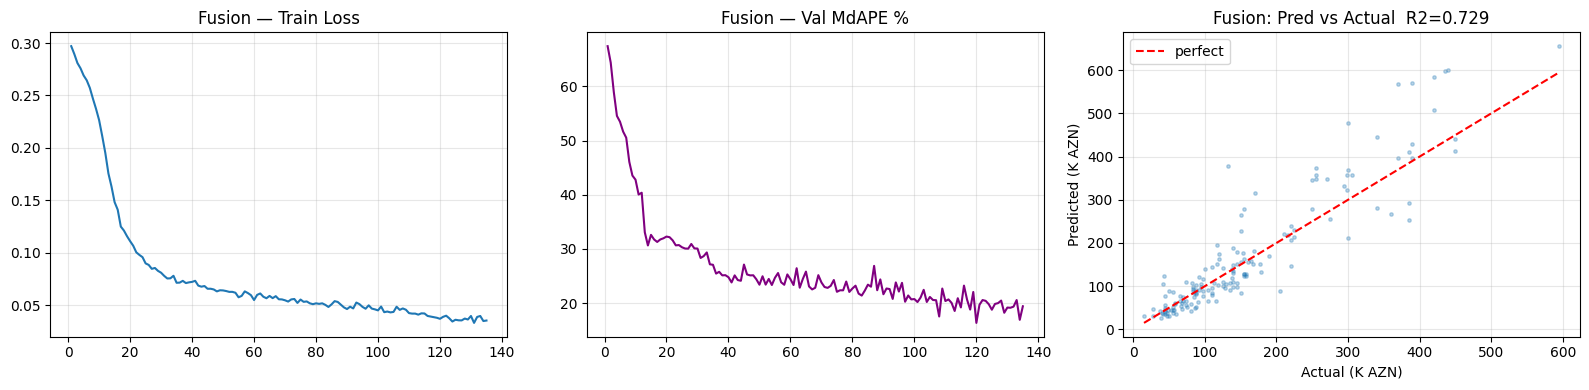

In [137]:
# ── Training curves + scatter plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

eps = range(1, len(history['loss']) + 1)
axes[0].plot(eps, history['loss'])
axes[0].set_title('Fusion — Train Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history['val_mdape'], color='purple')
axes[1].set_title('Fusion — Val MdAPE %'); axes[1].grid(alpha=0.3)

cap  = np.percentile(mm_targets_test, 95)
mask = mm_targets_test < cap
axes[2].scatter(mm_targets_test[mask]/1000, mm_preds_test[mask]/1000, alpha=0.3, s=6)
mn, mx = mm_targets_test[mask].min()/1000, mm_targets_test[mask].max()/1000
axes[2].plot([mn, mx], [mn, mx], 'r--', label='perfect')
axes[2].set_title(f'Fusion: Pred vs Actual  R2={r2_score(mm_targets_test, mm_preds_test):.3f}')
axes[2].set_xlabel('Actual (K AZN)'); axes[2].set_ylabel('Predicted (K AZN)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multimodal_results.png', dpi=120)
plt.show()

## 7. Save Models

In [138]:
torch.save({
    'fusion_model_state' : mm_model.state_dict(),
    'img_model_state'    : img_model.state_dict(),
    'scaler_mean'        : scaler.mean_,
    'scaler_scale'       : scaler.scale_,
    'tab_features'       : TAB_FEATURES,
    'y_mean'             : Y_MEAN,
    'y_std'              : Y_STD,
    'blend_alpha'        : best_alpha,
    'clip_dim'           : CLIP_DIM,
    'n_tab'              : N_TAB,
}, OUTPUT_DIR / 'multimodal_model.pt')
print('Models saved to', OUTPUT_DIR)

Models saved to ..\..\models\multimodal\house


## 8. Predict for a New House

In [147]:
def predict_multimodal(row_df):
    """
    row_df: single-row DataFrame with tabular features + 'house_id' + 'img_paths'
    """
    hid = int(row_df['house_id'].values[0])
    emb = embeddings[hid] if hid in embeddings else embed_house(row_df['img_paths'].values[0])

    tab_raw  = row_df[TAB_FEATURES].values.astype(np.float32)
    tab_norm = scaler.transform(tab_raw)

    mm_model.eval()
    with torch.no_grad():
        pred_norm = mm_model(emb.unsqueeze(0).to(device),
                             torch.tensor(tab_norm, dtype=torch.float32).to(device)).item()

    price = float(to_price(np.array([pred_norm]))[0])
    print(f'Fusion model estimate: {price:,.0f} AZN')
    return price

# Demo on first test house
demo_row = test_df.iloc[[7]]
print(f'Actual price: {demo_row[PRICE_COL].values[0]:,.0f} AZN')
predict_multimodal(demo_row)
print('Difference from actual:', abs(predict_multimodal(demo_row) - demo_row[PRICE_COL].values[0]), 'AZN')

Actual price: 177,000 AZN
Fusion model estimate: 150,438 AZN
Fusion model estimate: 150,438 AZN
Difference from actual: 26561.825224934495 AZN
